# **Data cleaning and business-rule validation**

Before analyzing product health the data is validated against the expected business rules:

- `user_id`, `trial_id`, `subscription_id`, and `payment_id` values are unique as primary keys
- Each user can have only 1 trial
- Each user can have only 1 registration date
- Non-nullable columns do not contain missing values
- Referential integrity:
    - Every payment is linked to an existing subscription
    - Every subscription is linked to an existing user
    - Every payment is linked to an existing user
    - Every trial is linked to an existing user
- Date rules:
    - Trial start dates are not earlier than user registration dates
    - Subscription start dates are not earlier than user registration dates
    - The first payment date matches the subscription start date
    - Trial periods always last 14 days
    - Billing cycles are always 1 month
- User age should be between 18 and 80, inclusive
- The 1st payment for each subscription is marked as `Initial`
- Subsequent payments are marked as `Renewal`
- Failed payments have an `amount_paid` value of `0`
- Failed payments always include a `failure_reason`
- Prices are: 7.99 for Basic, 14.99 for Premium

**As a result, there will be a table with all rules and outputs**

## **0.1. Data, libraries and functions import**

In [39]:
# -----------------
# loading libraries
# -----------------

import pandas as pd
import numpy as np
from scipy import stats
import statistics as s
import matplotlib.pyplot as plt
from IPython.display import display

In [40]:
# ------------------------------------------------------------------------------
# tables for storing the results of all data checks and rows with errors
# ------------------------------------------------------------------------------
final_result = []
failed_checks = {}

In [41]:
# -----------------
# loading functions
# -----------------

!git clone -q https://github.com/MariiaKrt/productivity-app-analysis.git

import sys
from pathlib import Path

ROOT = Path("/content/productivity-app-analysis")
sys.path.insert(0, str(ROOT / "src"))

from preprocessing import (
    bulk_convert_to_datetime,
    bulk_dupl_check,
    bulk_dates_check,
    bulk_periods_check,
    bulk_referential_integrity,
    bulk_date_to_month_week
)

from visualizing import exp_range

In [42]:
# ---------------
# loading sources
# ---------------

DATA_DIR = ROOT / "data" / "raw"

users = pd.read_csv(DATA_DIR / "users.csv")
trials = pd.read_csv(DATA_DIR / "trials.csv")
subscriptions = pd.read_csv(DATA_DIR / "subscriptions.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")

## **0.2. Data cleaning and business-rule validation**

####**0.2.1. General Overview of the sources**

In [43]:
# ---------------------------------------------------------------
# general overview of the sources: top rows
# ---------------------------------------------------------------

display(users.head())
print(' ')
display(trials.head())
print(' ')
display(subscriptions.head())
print(' ')
display(payments.head())

,user_id,registration_date,acquisition_channel,geo_region,device_type,age
0,U00001,2023-06-24,referral,North America,ios,20
1,U00002,2024-03-20,social,North America,android,21
2,U00003,2024-05-28,organic,Europe,android,33
3,U00004,2025-12-11,organic,North America,ios,41
4,U00005,2025-08-24,app_store_search,APAC,ios,22


,trial_id,user_id,trial_start_date,trial_end_date,trial_length_days
0,T00001,U00003,2024-05-29,2024-06-12,14
1,T00002,U00007,2024-05-13,2024-05-27,14
2,T00003,U00008,2024-08-20,2024-09-03,14
3,T00004,U00010,2025-07-18,2025-08-01,14
4,T00005,U00013,2024-10-21,2024-11-04,14


,subscription_id,user_id,subscription_start_date,subscription_end_date,status,current_plan,plan_change_date,auto_renew,cancellation_date
0,S00001,U05908,2025-08-24,NaN,active,Basic,NaN,True,NaN
1,S00002,U01372,2023-06-23,2023-07-23,expired,Basic,NaN,False,NaN
2,S00003,U06016,2023-08-29,NaN,active,Basic,NaN,True,NaN
3,S00004,U01275,2022-10-01,2022-11-01,canceled,Basic,NaN,True,2022-10-18
4,S00005,U06500,2024-01-27,2024-10-27,canceled,Basic,NaN,True,2024-10-11


,payment_id,subscription_id,user_id,payment_start_date,payment_status,payment_type,billing_period_start,billing_period_end,amount_paid,failure_reason,payment_provider,card_type
0,P000001,S00001,U05908,2025-08-24,succeeded,initial,2025-08-24,2025-09-24,7.99,NaN,web_card,mastercard
1,P000002,S00001,U05908,2025-09-24,succeeded,renewal,2025-09-24,2025-10-24,7.99,NaN,web_card,mastercard
2,P000003,S00001,U05908,2025-10-24,succeeded,renewal,2025-10-24,2025-11-24,7.99,NaN,web_card,mastercard
3,P000004,S00001,U05908,2025-11-24,succeeded,renewal,2025-11-24,2025-12-24,7.99,NaN,web_card,mastercard
4,P000005,S00001,U05908,2025-12-24,succeeded,renewal,2025-12-24,2026-01-24,7.99,NaN,web_card,mastercard


In [44]:
# ------------------------------------------------------------------
# general overview of the sources: basic stats
# ------------------------------------------------------------------

display(users.describe(include = 'all'))
print(' ')
display(trials.describe(include = 'all'))
print(' ')
display(subscriptions.describe(include = 'all'))
print(' ')
display(payments.describe(include = 'all'))

,user_id,registration_date,acquisition_channel,geo_region,device_type,age
count,7700,7700,7700,7700,7700,7700.000000
unique,7700,1215,6,5,2,NaN
top,U07456,2025-05-06,app_store_search,North America,ios,NaN
freq,1,23,1791,2683,4641,NaN
mean,NaN,NaN,NaN,NaN,NaN,33.572338
std,NaN,NaN,NaN,NaN,NaN,9.604510
min,NaN,NaN,NaN,NaN,NaN,18.000000
25%,NaN,NaN,NaN,NaN,NaN,26.000000
50%,NaN,NaN,NaN,NaN,NaN,33.000000
75%,NaN,NaN,NaN,NaN,NaN,41.000000


,trial_id,user_id,trial_start_date,trial_end_date,trial_length_days
count,4044,4044,4044,4044,4044.0
unique,4044,4044,1123,1123,NaN
top,T04044,U07000,2025-12-17,2025-12-31,NaN
freq,1,1,42,42,NaN
mean,NaN,NaN,NaN,NaN,14.0
std,NaN,NaN,NaN,NaN,0.0
min,NaN,NaN,NaN,NaN,14.0
25%,NaN,NaN,NaN,NaN,14.0
50%,NaN,NaN,NaN,NaN,14.0
75%,NaN,NaN,NaN,NaN,14.0


,subscription_id,user_id,subscription_start_date,subscription_end_date,status,current_plan,plan_change_date,auto_renew,cancellation_date
count,3416,3416,3416,2474,3416,3416,485,3416,1898
unique,3416,3330,1103,939,3,3,344,2,862
top,S03416,U04684,2024-05-22,2025-02-28,canceled,Basic,2025-03-19,True,2025-10-03
freq,1,2,13,11,1898,2749,6,2456,7


,payment_id,subscription_id,user_id,payment_start_date,payment_status,payment_type,billing_period_start,billing_period_end,amount_paid,failure_reason,payment_provider,card_type
count,23864,23864,23864,23864,23864,23864,23864,23864,23864.000000,592,23864,12201
unique,23864,3416,3330,1239,2,2,1239,1217,NaN,6,5,5
top,P023866,S02642,U07001,2025-02-28,succeeded,renewal,2025-02-28,2025-02-28,NaN,insufficient_funds,apple_app_store,visa
freq,1,42,42,117,23272,20432,117,122,NaN,149,8837,3822
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.120277,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.099351,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.990000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.990000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.990000,NaN,NaN,NaN


In [45]:
# ----------------------------------------------------------------
# general overview of the sources: null rows
# ----------------------------------------------------------------

display(users.isna().sum())
print(' ')
display(trials.isna().sum())
print(' ')
display(subscriptions.isna().sum())
print(' ')
display(payments.isna().sum())

,0
user_id,0
registration_date,0
acquisition_channel,0
geo_region,0
device_type,0
age,0


,0
trial_id,0
user_id,0
trial_start_date,0
trial_end_date,0
trial_length_days,0


,0
subscription_id,0
user_id,0
subscription_start_date,0
subscription_end_date,942
status,0
current_plan,0
plan_change_date,2931
auto_renew,0
cancellation_date,1518


,0
payment_id,0
subscription_id,0
user_id,0
payment_start_date,0
payment_status,0
payment_type,0
billing_period_start,0
billing_period_end,0
amount_paid,0
failure_reason,23272


#### **0.2.2. Column conversion to work with them further**

In [46]:
# ------------------------------------------------------------------------------
# applying pd.to_datetime to date columns
# ------------------------------------------------------------------------------
columns = [(users, 'registration_date'),
           (trials, 'trial_start_date'),
           (trials, 'trial_end_date'),
           (payments, 'payment_start_date'),
           (payments, 'billing_period_start'),
           (payments, 'billing_period_end'),
           (subscriptions, 'subscription_start_date'),
           (subscriptions, 'subscription_end_date'),
           (subscriptions, 'plan_change_date'),
           (subscriptions, 'cancellation_date')]

bulk_convert_to_datetime (columns)

#### **0.2.3.Checking data and business rules**

In [47]:
# --------------------------------------------------------------------------------------------------
# checking that
# user_id, trial_id, subscription_id, and payment_id values are unique as primary keys
# user_id can have only 1 trial
# user_id can have only 1 regstration date
# --------------------------------------------------------------------------------------------------

dup_checks = [(users, 'user_id', failed_checks, final_result, 'users'),
          (trials, 'trial_id', failed_checks, final_result, 'trials'),
          (trials, 'user_id', failed_checks, final_result, 'trials'),
          (subscriptions, 'subscription_id', failed_checks, final_result, 'subscriptions'),
          (payments, 'payment_id', failed_checks, final_result, 'payments')
          ]

duplicates = bulk_dupl_check (dup_checks)
display(duplicates)

['PASS | 0 user_ids of 7700 are duplicated in users',
 'PASS | 0 trial_ids of 4044 are duplicated in trials',
 'PASS | 0 user_ids of 4044 are duplicated in trials',
 'PASS | 0 subscription_ids of 3416 are duplicated in subscriptions',
 'PASS | 0 payment_ids of 23864 are duplicated in payments']

In [48]:
# ------------------------------------------------------------------------------
# Checking referential integrity:
# - every payment is linked to an existing subscription
# - every subscription is linked to an existing payment
# - every subscription is linked to an existing user
# - every payment is linked to an existing user
# - every trial is linked to an existing user
# ------------------------------------------------------------------------------

data_check = [(subscriptions, payments, 'subscription_id', 'subscriptions', 'payments', failed_checks, final_result, 'outer'),
              (subscriptions, users, 'user_id', 'subscriptions', 'users', failed_checks, final_result, 'left'),
              (payments, users, 'user_id', 'payments', 'users', failed_checks, final_result, 'left'),
              (trials, users, 'user_id', 'trials', 'users', failed_checks, final_result, 'left')
              ]

referential_int = bulk_referential_integrity (data_check)
display(referential_int)

['PASS | 0 subscription_ids in subscriptions, payments do not match',
 'PASS | 0 user_ids in subscriptions, users do not match',
 'PASS | 0 user_ids in payments, users do not match',
 'PASS | 0 user_ids in trials, users do not match']

In [49]:
# --------------------------------------------------------------------------------------------------------------------------------
# - registration date <= trial start date
# - trial start date <= trial end date
# - registration date <= subscription start date
# - subscription start date <= subscription end date | Important: subscription end date is null if the subscription is not ended
# - subscription start date >= trial start date | Important: not all users have trial
# - subscription start date = payment date
# --------------------------------------------------------------------------------------------------------------------------------

# pre check: subscription end date can only be null if a subscription status = active
wrong_non_active_end = len(subscriptions[(subscriptions['status'] != 'active') & subscriptions['subscription_end_date'].isna()])
wrong_active_end = len(subscriptions[(subscriptions['status'] == 'active') & ~subscriptions['subscription_end_date'].isna()])
print(f'End subscription dates are empty for the inactive subscriptions: {wrong_non_active_end}')
print(f'End subscription dates are not empty for the active subscriptions: {wrong_active_end}')
print(' ')



paym_min_dt_by_subcr = payments.groupby('subscription_id', as_index = False)['payment_start_date'].min()
non_active_subscriptions = subscriptions[(subscriptions['status'] != 'active')].copy()

date_checks = [(users, trials, 'registration_date', 'trial_start_date', 'user_id', 'user_id', failed_checks, final_result, 'users', 'trials', False, '>'),
               (trials, trials, 'trial_start_date', 'trial_end_date', 'trial_id', 'trial_id', failed_checks, final_result, 'trials', 'trials', True, '>'),
               (trials, subscriptions, 'trial_start_date', 'subscription_start_date', 'user_id', 'user_id', failed_checks, final_result, 'subscriptions', 'trials', False, '>'),
               (users, subscriptions, 'registration_date', 'subscription_start_date', 'user_id', 'user_id', failed_checks, final_result, 'users', 'subscriptions', False, '>'),
               (non_active_subscriptions, non_active_subscriptions, 'subscription_start_date', 'subscription_end_date', 'subscription_id', 'subscription_id', failed_checks, final_result, 'subscriptions', 'subscriptions', True, '>'),
               (subscriptions, paym_min_dt_by_subcr, 'subscription_start_date', 'payment_start_date', 'subscription_id', 'subscription_id', failed_checks, final_result, 'subscriptions', 'payments', False, '!=')
               ]

dates_rules = bulk_dates_check (date_checks)
display(dates_rules)

End subscription dates are empty for the inactive subscriptions: 0
End subscription dates are not empty for the active subscriptions: 0
 


['PASS | 0 registration_dates > trial_start_date in users x trials',
 'PASS | 0 trial_start_dates > trial_end_date in trials',
 'PASS | 0 trial_start_dates > subscription_start_date in subscriptions x trials',
 'PASS | 0 registration_dates > subscription_start_date in users x subscriptions',
 'PASS | 0 subscription_start_dates > subscription_end_date in subscriptions',
 'PASS | 0 subscription_start_dates != payment_start_date in subscriptions x payments']

(                             Values
 Null values & share:       [0, 0.0]
 Allowed range:             [18, 81]
 Actual column range:   [18.0, 54.0]
 Minimum check passed:          True
 Maximum check passed:          True
 Mean:                       33.5723
 Median:                     33.0000
 25th percentile:            26.0000
 75th percentile:            41.0000
 IQR:                        15.0000
 Skewness:                    0.2515,
 <Figure size 1800x500 with 2 Axes>)

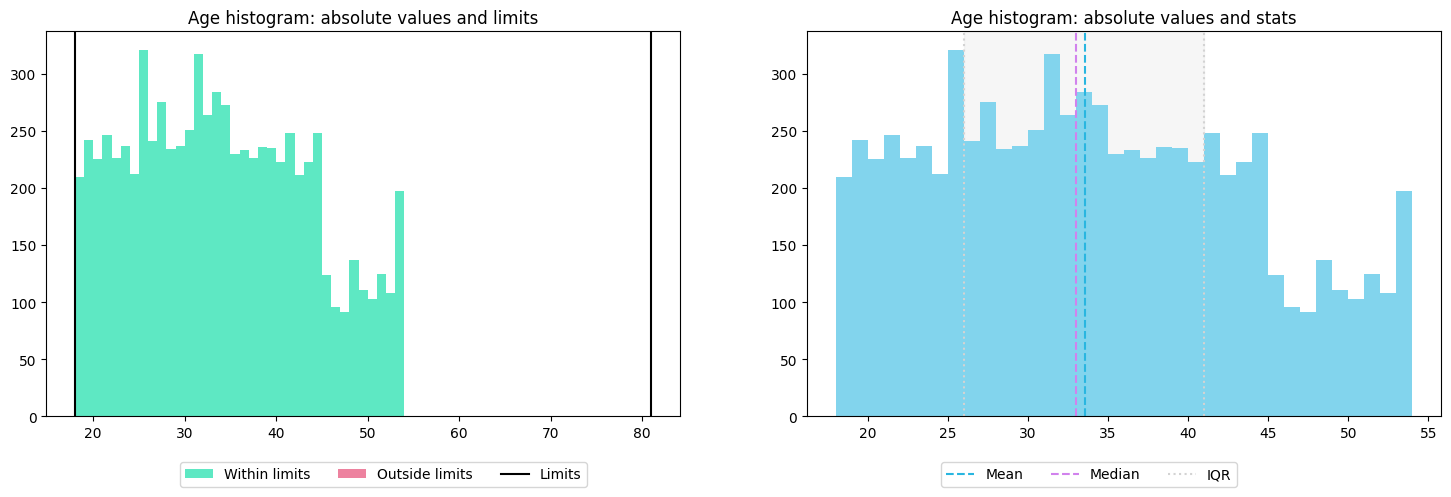

In [50]:
# ------------------------------------------------------------------------------
# Analysis of Age column:
# - range between 18 and 80
# ------------------------------------------------------------------------------

exp_range('age', 'users', users, 'age', failed_checks, final_result, allowable_min_incl = 18, allowable_max_excl = 81, bins_size = 1, result = 'both')

In [51]:
# ------------------------------------------------------------------------------
# Validating periods:
# - trial can only be 14 days
# - billing period should be 1 month
# ------------------------------------------------------------------------------

data_check = [(trials, 'trials', 'trial_start_date', 'trial_end_date', 14, 'day', failed_checks, final_result, False),
              (payments, 'payments', 'billing_period_start', 'billing_period_end', 1, 'month', failed_checks, final_result, False)]

bulk_periods_check(data_check)

['PASS | 0 rows where difference between trial_start_date and trial_end_date is not 14 day(s)',
 'PASS | 0 rows where difference between billing_period_start and billing_period_end is not 1 month(s)']

In [52]:
# ------------------------------------------------------------------------------
# Checking:
# - The 1st successful payment by subscription is marked as `Initial`
# - Subsequent payments are marked as `Renewal`
# - Failed payments have an `amount_paid` value of `0`
# - Failed payments always include a `failure_reason`
# ------------------------------------------------------------------------------

# finding minimum payment date by subscription
payments_prep = payments[payments['payment_status'] != 'failed']
min_date_by_subscription = payments_prep.groupby('subscription_id', as_index = False)['payment_start_date'].min()

# adding minimum dates to the table
payment_check = payments_prep.merge(min_date_by_subscription,
                                    on = ['subscription_id', 'payment_start_date'],
                                    how = 'left',
                                    indicator = True)

wrong_transaction_type_init = payment_check[(payment_check['payment_type'] != 'initial') & (payment_check['_merge'] == 'both')]
wrong_transaction_type_renew = payment_check[(payment_check['payment_type'] != 'renewal') & (payment_check['_merge'] == 'left_only')]
failed_payment_amount = payments[(payments['payment_status'] == 'failed') & (payments['amount_paid'] != 0)]
successful_payment_amount = payments[(payments['payment_status'] != 'failed') & (payments['amount_paid'] == 0)]
failure_reason_filled = payments[(payments['payment_status'] == 'failed') & (payments['failure_reason'].isna())]

wrong_transaction_type_init_res = len(wrong_transaction_type_init)
wrong_transaction_type_renew_res = len(wrong_transaction_type_renew)
failed_payment_amount_res = len(failed_payment_amount)
successful_payment_amount_res = len(successful_payment_amount)
failure_reason_filled_res = len(failure_reason_filled)

results = [wrong_transaction_type_init_res,
       wrong_transaction_type_renew_res,
       failed_payment_amount_res,
       successful_payment_amount_res,
       failure_reason_filled_res]
tables = [wrong_transaction_type_init,
       wrong_transaction_type_renew,
       failed_payment_amount,
       successful_payment_amount,
       failure_reason_filled]
names = ['wrong_transaction_type_initial',
         'wrong_transaction_type_renewal',
         'failed_payment_amount',
         'successful_payment_amount',
         'failure_reason_is_empty']

for r, t, n in zip(results, tables, names):
  if r != 0:
    failed_checks[n] = t

wrong_transaction_type_i_res = (f'FAIL | {wrong_transaction_type_init_res} rows have wrong transaction type - 1st payment and not Initial' \
                                  if wrong_transaction_type_init_res != 0 \
                                  else f'PASS | {wrong_transaction_type_init_res} rows have wrong transaction type - 1st payment and not Initial')
wrong_transaction_type_r_res = (f'FAIL | {wrong_transaction_type_renew_res} rows have wrong transaction type - not 1st payment and not Renewal' \
                                if wrong_transaction_type_renew_res != 0 \
                                else f'PASS | {wrong_transaction_type_renew_res} rows have wrong transaction type - not 1st payment and not Renewal')
failed_payment_amount_0_res = (f'FAIL | {failed_payment_amount_res} rows where failed payment has amount' \
                               if failed_payment_amount_res != 0 \
                               else f'PASS | {failed_payment_amount_res} rows where failed payment has amount')
successful_payment_amount_not_0_res = (f'FAIL | {successful_payment_amount_res} rows where successful payment has no amount' \
                                if successful_payment_amount_res != 0 \
                                else f'PASS | {successful_payment_amount_res} rows where successful payment has no amount')
failure_reason_not_filled_res = (f'FAIL | {failure_reason_filled_res} rows where failed payment does not have a reason' \
                               if failure_reason_filled_res != 0 \
                               else f'PASS | {failure_reason_filled_res} rows where failed payment does not have a reason')

final_result.append(('Initial is assigned incorrectly', wrong_transaction_type_i_res, None if wrong_transaction_type_init_res == 0 else 'wrong_transaction_type_initial'))
final_result.append(('Renewal is assigned incorrectly', wrong_transaction_type_r_res, None if wrong_transaction_type_renew_res == 0 else 'wrong_transaction_type_renewal'))
final_result.append(('Amount > 0 for failed payments', failed_payment_amount_0_res, None if failed_payment_amount_res == 0 else 'failed_payment_amount'))
final_result.append(('Amount 0 for successful payments', successful_payment_amount_not_0_res, None if successful_payment_amount_res == 0 else 'successful_payment_amount'))
final_result.append(('Failure reason is empty', failure_reason_not_filled_res, None if failure_reason_filled_res == 0 else 'failure_reason_is_empty'))

print(wrong_transaction_type_i_res)
print(wrong_transaction_type_r_res)
print(failed_payment_amount_0_res)
print(successful_payment_amount_not_0_res)
print(failure_reason_not_filled_res)


PASS | 0 rows have wrong transaction type - 1st payment and not Initial
PASS | 0 rows have wrong transaction type - not 1st payment and not Renewal
PASS | 0 rows where failed payment has amount
PASS | 0 rows where successful payment has no amount
PASS | 0 rows where failed payment does not have a reason


In [53]:
# -----------------------------------------------------------------------------------
# Checking:
# - if plan_change_date is null, the payment amount must match the current plan price
# - if plan_change_date is not null:
#     - payments before plan_change_date must match the previous plan price
#     - payments on or after plan_change_date must match the current plan price
# -----------------------------------------------------------------------------------

print(f'Plans in subscriptions (initial source): {subscriptions['current_plan'].unique()}')

# There is 'Basic' and 'basic'. This needs to be unified
subscriptions_adjusted = subscriptions.copy()
subscriptions_adjusted['current_plan'] = subscriptions_adjusted['current_plan'].str.capitalize()

print(f'Plans in subscriptions (initial source): {subscriptions_adjusted['current_plan'].unique()}')

# checking prices in the data
print('Prices in the payments table:', payments[payments['payment_status'] == 'succeeded']['amount_paid'].unique())

# creating prices dictionary
prices = pd.DataFrame.from_dict({'Basic': 7.99,
                                'Premium': 14.99},
                                 orient = 'index',
                                 columns = ['price']).reset_index(names = 'type')

# validating prices
plan_changed = (subscriptions_adjusted[~subscriptions_adjusted['plan_change_date'].isna()]
                             [['subscription_id', 'plan_change_date']]
                             .rename(columns = {'plan_change_date': 'plan_changed'}))

# check the number of plan changes per subscription
number_of_plan_changes = plan_changed.groupby('subscription_id')['plan_changed'].nunique()
max_number_of_plan_changes = number_of_plan_changes.max()
print(f'Maximum number of plan changes per subscription: {max_number_of_plan_changes}')


# reconstructing the historical plan
payments_prep = payments[payments['amount_paid'] != 0][['payment_id', 'subscription_id', 'billing_period_start', 'amount_paid']]
payments_prep = (payments_prep.merge(subscriptions_adjusted,
                                     on = 'subscription_id',
                                     how = 'left')
                                     [['payment_id', 'subscription_id', 'billing_period_start', 'amount_paid', 'current_plan']])

merged = (payments_prep.merge(plan_changed,
                              on = 'subscription_id',
                              how = 'left'))

merged['plan_changed_flag'] = (merged['plan_changed'].fillna(pd.Timestamp.max) <= merged['billing_period_start'])

conditions = [((~merged['plan_changed'].isna()) & ~merged['plan_changed_flag'] & (merged['current_plan'] == 'Basic')),
              ((~merged['plan_changed'].isna()) & ~merged['plan_changed_flag'] & (merged['current_plan'] == 'Premium'))]

choices = ['Premium',
           'Basic']

merged['updated_plan'] = np.select(conditions, choices, merged['current_plan'])

merged = merged.merge(prices, left_on = 'updated_plan', right_on = 'type', how = 'left')

# compare prices paid to the historical plan
merged_wrong_prices = merged['price'] != merged['amount_paid']

wrong_prices = sum(merged_wrong_prices)

result = (f'FAIL | {wrong_prices} rows have wrong prices' \
                    if wrong_prices != 0 \
                    else f'PASS | {wrong_prices} rows have wrong prices')

if wrong_prices != 0:
  check_name = 'wrong_prices'
  failed_checks[check_name] = merged[merged_wrong_prices]
  final_result.append(('Wrong prices', result, check_name))
else:
  final_result.append(('Wrong prices', result, None))

print(result)


Plans in subscriptions (initial source): ['Basic' 'Premium' 'basic']
Plans in subscriptions (initial source): ['Basic' 'Premium']
Prices in the payments table: [ 7.99 14.99]
Maximum number of plan changes per subscription: 1
PASS | 0 rows have wrong prices


####**Results**

In [54]:
# ---------
# Results
# ---------

final_result = (pd.DataFrame(final_result))
columns = ['Category', 'Result', 'Key to failed_checks']
final_result.columns = columns
final_result[['Status', 'Result']] = final_result['Result'].str.split('|', expand = True)
final_result = final_result.drop_duplicates()

if final_result['Key to failed_checks'].isna().all():
  display(final_result[['Category', 'Status', 'Result']])
else:
  display(final_result[['Category', 'Status', 'Result', 'Key to failed_checks']])

,Category,Status,Result
0,Duplicates,PASS,0 user_ids of 7700 are duplicated in users
1,Duplicates,PASS,0 trial_ids of 4044 are duplicated in trials
2,Duplicates,PASS,0 user_ids of 4044 are duplicated in trials
3,Duplicates,PASS,0 subscription_ids of 3416 are duplicated in ...
4,Duplicates,PASS,0 payment_ids of 23864 are duplicated in paym...
5,Referential integrity,PASS,"0 subscription_ids in subscriptions, payments..."
6,Referential integrity,PASS,"0 user_ids in subscriptions, users do not match"
7,Referential integrity,PASS,"0 user_ids in payments, users do not match"
8,Referential integrity,PASS,"0 user_ids in trials, users do not match"
9,Date columns rules,PASS,0 registration_dates > trial_start_date in us...


All validation checks passed.
Inconsistency in the plan naming is corrected.
The data is consistent with the business rules and can be used for product-health analysis

## **0.3. Data pre-processing**

Adding month and week columns to the sources for the future usage

In [55]:
# ------------------------------------------------------------------------------
# applying date_to_month funtion to date columns
# ------------------------------------------------------------------------------

users_adjusted = users.copy()
trials_adjusted = trials.copy()
payments_adjusted = payments.copy()

tables = [(users_adjusted, 'registration_date', 'Month', 'registration_month', True),
          (users_adjusted, 'registration_date', 'Week', 'registration_week', True),
          (subscriptions_adjusted, 'subscription_start_date', 'Month', 'subscription_month', True),
          (subscriptions_adjusted, 'cancellation_date', 'Month', 'cancellation_month', True),
          (subscriptions_adjusted, 'subscription_end_date', 'Month', 'subscription_end_month', True),
          (trials_adjusted, 'trial_start_date', 'Month', 'trial_start_month', True),
          (payments_adjusted, 'payment_start_date', 'Month', 'payment_month', True)]

bulk_date_to_month_week (tables)

##**0.4. Adjusted tables**
The tables with:
- corrected plan naming
- week and month columns

to export for the further use

In [56]:
users_adjusted.to_csv('users_adjusted.csv', index = False)
trials_adjusted.to_csv('trials_adjusted.csv', index = False)
subscriptions_adjusted.to_csv('subscriptions_adjusted.csv', index = False)
payments_adjusted.to_csv('payments_adjusted.csv', index = False)